# PyVelrot — Validation Notebook

**PyVelrot** is a Python reimplementation of the GAMIT/GLOBK Fortran program `velrot.f`
(T. Herring et al.).  It estimates a Helmert transformation (translations + rotations,
optionally + scale) between two GNSS velocity fields using weighted least squares, then
writes the transformed System 1 velocities together with the System 2 sites.

This notebook validates PyVelrot against precomputed output from the original Fortran
`velrot` binary.  **GAMIT/GLOBK is not required to run this notebook.**

---

## Test case

| Item | File | Description |
|------|------|-------------|
| System 1 | `data/reilinger_2006.vel` | 429 published GNSS velocities (Reilinger et al. 2006) |
| System 2 | `data/serpelloni_2022.vel` | 3252 European IGb14 velocities (Serpelloni et al. 2022) |
| Links | `data/velrot.lnk` | `eq_dist 1000` — links all site pairs within 1000 m |
| Options | `TR`, height_weight=0 | 6-parameter Helmert (translations + rotations), horizontal only |
| Reference | `reference/reilinger_2006_igb14.tmp` | Precomputed Fortran `velrot` output |

In [8]:
import sys
import io
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Notebook must be run from the PyVelrot/ directory
REPO = Path.cwd()
sys.path.insert(0, str(REPO))

from pyvelrot import PyVelrot

print(f"Repo: {REPO}")
for f in ["pyvelrot.py",
          "data/reilinger_2006.vel",
          "data/serpelloni_2022.vel",
          "data/velrot.lnk",
          "reference/reilinger_2006_igb14.tmp"]:
    status = "OK" if (REPO / f).exists() else "MISSING"
    print(f"  [{status}] {f}")

Repo: /Users/nicolas/Common_bin/gamit_source/source/kf/utils/PyVelrot
  [OK] pyvelrot.py
  [OK] data/reilinger_2006.vel
  [OK] data/serpelloni_2022.vel
  [OK] data/velrot.lnk
  [OK] reference/reilinger_2006_igb14.tmp


## Helper functions

Utilities to parse `.vel` files and velrot output headers.

In [9]:
def parse_vel_file(path, section=None):
    """Read a GAMIT .vel file or a named section of a velrot .tmp file.

    section: None = all data lines, 'sys1' = SYSTEM 1 block, 'sys2' = SYSTEM 2 block.
    """
    cols = "lon lat ve vn de dn se sn rho vu du su site".split()
    records = []
    in_sec = (section is None)
    with open(path) as f:
        for line in f:
            s = line.rstrip("\n")
            if section == "sys1":
                if "SYSTEM 1 Velocities transformed" in s:
                    in_sec = True; continue
                if "SYSTEM 2 Velocities" in s:
                    break
            elif section == "sys2":
                if "SYSTEM 2 Velocities" in s:
                    in_sec = True; continue
            if not in_sec or not s or s[0] != " ":
                continue
            toks = s.split()
            if len(toks) < 12:
                continue
            try:
                row = [float(t) for t in toks[:12]]
                row.append(toks[12].rstrip("*+") if len(toks) > 12 else "")
                records.append(row)
            except ValueError:
                pass
    return pd.DataFrame(records, columns=cols)


def parse_velrot_summary(path):
    """Parse transformation parameters and statistics from a velrot output header."""
    lab_map = {
        "X-Offset": "Tx", "Y-Offset": "Ty", "Z-Offset": "Tz",
        "X-Rot": "Rx",    "Y-Rot": "Ry",    "Z-Rot": "Rz",  "Scale": "Scale",
    }
    p = {}
    with open(path) as f:
        for raw in f:
            s = raw.strip()
            if "RMS fit for" in s and "components" in s:
                # * RMS fit for <N> components from <M> stations was <rms> mm/yr, NRMS <chi>
                toks = s.split()
                try:
                    p["num_data"] = int(toks[4]); p["num_fund"] = int(toks[7])
                    p["rms_mm_yr"] = float(toks[10]); p["chi_fit"] = float(toks[13])
                except (IndexError, ValueError):
                    pass
            elif s.startswith("*"):
                toks = s.split()
                if len(toks) >= 5 and toks[2] in lab_map:
                    try:
                        k = lab_map[toks[2]]
                        p[k] = float(toks[3]); p[f"sigma_{k}"] = float(toks[4])
                    except (ValueError, IndexError):
                        pass
    return p

---
## 1. Run PyVelrot

Estimate the 6-parameter Helmert transformation between the two velocity fields
and write the transformed System 1 velocities to `output/reilinger_2006_igb14_python.tmp`.

In [10]:
import os
os.makedirs("output", exist_ok=True)

buf = io.StringIO()
with redirect_stdout(buf):
    vr = PyVelrot()
    vr.run(
        sys1_file="data/reilinger_2006.vel",
        sys1_frame="NONE",
        sys2_file="data/serpelloni_2022.vel",
        sys2_frame="NONE",
        out_file="output/reilinger_2006_igb14_python.tmp",
        out_frame="NONE",
        fund_file="data/velrot.lnk",
        height_weight=0,
        param_opt="TR",
    )
run_log = buf.getvalue()
print(run_log[:600])


 VELROT: Velocity field comparison and combination Version 1.01

 There are   429 sites in sys file data/reilinger_2006.vel
 Rotating from NONE       to NONE       using rotation vector     0.000000     0.000000     0.000000 degs/Myrs
 There are  3252 sites in sys file data/serpelloni_2022.vel
 Rotating from NONE       to NONE       using rotation vector     0.000000     0.000000     0.000000 degs/Myrs
 There are   178 matching sites in fundamental file data/velrot.lnk
S Component North #   178 WMean   0.03 WRMS   0.67 mm/yr, NRMS   1.281
S Component East #   178 WMean   0.01 WRMS   0.74 mm/y


---
## 2. Transformation Parameters

Compare the estimated parameters against the Fortran reference.

In [11]:
fort = parse_velrot_summary("reference/reilinger_2006_igb14.tmp")
py   = vr.get_parameters()

param_keys = ["Tx", "Ty", "Tz", "Rx", "Ry", "Rz"]
units       = ["mm/yr", "mm/yr", "mm/yr", "mas/yr", "mas/yr", "mas/yr"]

rows = []
for k, u in zip(param_keys, units):
    fv, fs = fort.get(k, float("nan")), fort.get(f"sigma_{k}", float("nan"))
    pv, ps = py.get(k, float("nan")),   py.get(f"sigma_{k}", float("nan"))
    rows.append({"Param": k, "Units": u,
                 "Fortran":  f"{fv:+.4f} ± {fs:.4f}",
                 "Python":   f"{pv:+.4f} ± {ps:.4f}",
                 "Diff":     f"{pv - fv:+.5f}"})

df_par = pd.DataFrame(rows)
print("Transformation parameters (Fortran reference vs Python):")
print(df_par.to_string(index=False))
print()
print(f"  RMS (mm/yr) :  Fortran {fort['rms_mm_yr']:.2f}   Python {py['rms_mm_yr']:.2f}")
print(f"  NRMS        :  Fortran {fort['chi_fit']:.2f}   Python {py['chi_fit']:.2f}")
print(f"  N components:  Fortran {fort['num_data']}     Python {py['num_data']}")

Transformation parameters (Fortran reference vs Python):
Param  Units          Fortran           Python     Diff
   Tx  mm/yr +0.7551 ± 0.1766 +0.7521 ± 0.1762 -0.00301
   Ty  mm/yr +0.0674 ± 0.2367 +0.0667 ± 0.2365 -0.00065
   Tz  mm/yr +0.7002 ± 0.2621 +0.7027 ± 0.2623 +0.00248
   Rx mas/yr -0.0924 ± 0.0058 -0.0924 ± 0.0058 -0.00003
   Ry mas/yr -0.5290 ± 0.0077 -0.5290 ± 0.0077 +0.00000
   Rz mas/yr +0.7490 ± 0.0085 +0.7490 ± 0.0084 +0.00002

  RMS (mm/yr) :  Fortran 0.72   Python 0.72
  NRMS        :  Fortran 1.35   Python 1.35
  N components:  Fortran 356     Python 356


---
## 3. Per-site Velocity Comparison

Compare the transformed System 1 velocities from PyVelrot (via `get_sys1_velocities()`)
against the SYSTEM 1 section of the Fortran reference output.

> The input dataset contains one site name (DERB_GPS) at two distinct geographic
> locations.  Comparison is done **row-by-row** (same processing order) rather than
> by merging on site name, to avoid artificially inflated match counts.

In [12]:
# Fortran reference — SYSTEM 1 transformed velocities
df_ref = parse_vel_file("reference/reilinger_2006_igb14.tmp", section="sys1")

# Python output — get_sys1_velocities() returns same row order as input
py_vels  = vr.get_sys1_velocities()
df_py    = pd.DataFrame(py_vels)

n = len(df_ref)
assert len(df_py) == n, f"Row count mismatch: reference {n}, Python {len(df_py)}"
print(f"Comparing {n} System 1 sites (row-by-row)")
print()

# Residuals
dve = df_py["ve"].values - df_ref["ve"].values
dvn = df_py["vn"].values - df_ref["vn"].values
dvu = df_py["vu"].values - df_ref["vu"].values

print("Residual statistics  (PyVelrot − Fortran reference):")
print(f"  {'Component':10s}  {'mean':>8s}  {'std':>8s}  {'max|d|':>8s}  unit")
for comp, d, u in [("East Ve", dve, "mm/yr"),
                    ("North Vn", dvn, "mm/yr"),
                    ("Up Vu",   dvu, "mm/yr")]:
    print(f"  {comp:10s}  {d.mean():+8.4f}  {d.std():8.4f}  {abs(d).max():8.4f}  {u}")
print()
print("Horizontal residuals ≤ 0.01 mm/yr reflect the .vel format's 2-decimal-place")
print("display precision (±0.005 mm/yr rounding).  Up residuals ≤ 0.06 mm/yr arise")
print("from floating-point differences between numpy and Fortran's linear solver.")

Comparing 429 System 1 sites (row-by-row)

Residual statistics  (PyVelrot − Fortran reference):
  Component       mean       std    max|d|  unit
  East Ve      +0.0004    0.0029    0.0064  mm/yr
  North Vn     -0.0003    0.0030    0.0061  mm/yr
  Up Vu        +0.0344    0.0165    0.0580  mm/yr

Horizontal residuals ≤ 0.01 mm/yr reflect the .vel format's 2-decimal-place
display precision (±0.005 mm/yr rounding).  Up residuals ≤ 0.06 mm/yr arise
from floating-point differences between numpy and Fortran's linear solver.


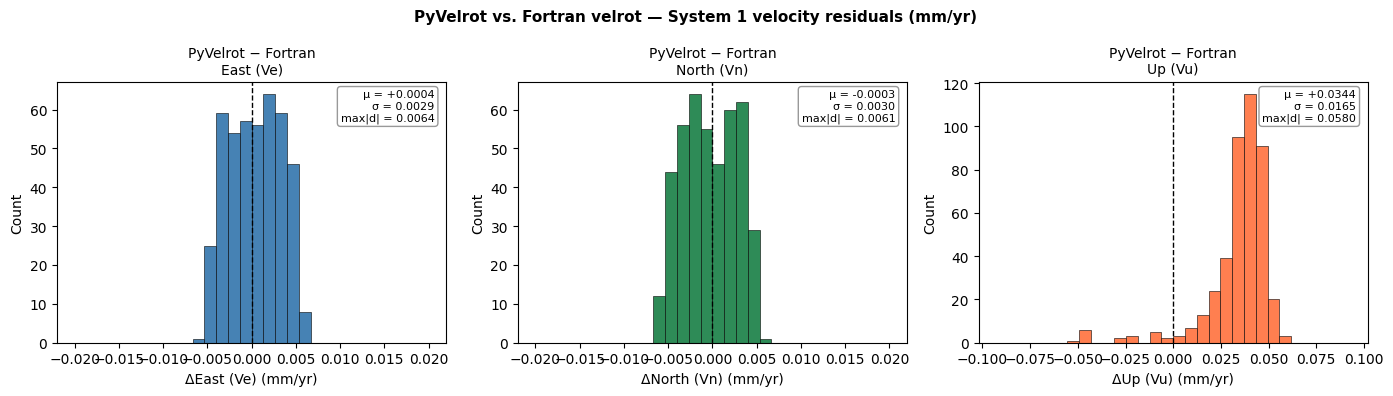

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["steelblue", "seagreen", "coral"]

for ax, d, label, color in zip(
        axes,
        [dve, dvn, dvu],
        ["East (Ve)", "North (Vn)", "Up (Vu)"],
        colors):
    rng = max(abs(d).max() * 1.6, 0.02)
    ax.hist(d, bins=30, range=(-rng, rng),
            color=color, edgecolor="k", linewidth=0.4)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel(f"\u0394{label} (mm/yr)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"PyVelrot \u2212 Fortran\n{label}", fontsize=10)
    ax.text(0.97, 0.97,
            f"\u03bc = {d.mean():+.4f}\n\u03c3 = {d.std():.4f}\nmax|d| = {abs(d).max():.4f}",
            transform=ax.transAxes, va="top", ha="right", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))

fig.suptitle("PyVelrot vs. Fortran velrot — System 1 velocity residuals (mm/yr)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Velocity Field Visualization

The quiver plots below show the System 1 velocity field before transformation
(in the original frame) and after transformation (aligned to the System 2 IGb14 frame).
Arrow colour encodes velocity magnitude; scale bar = 10 mm/yr.

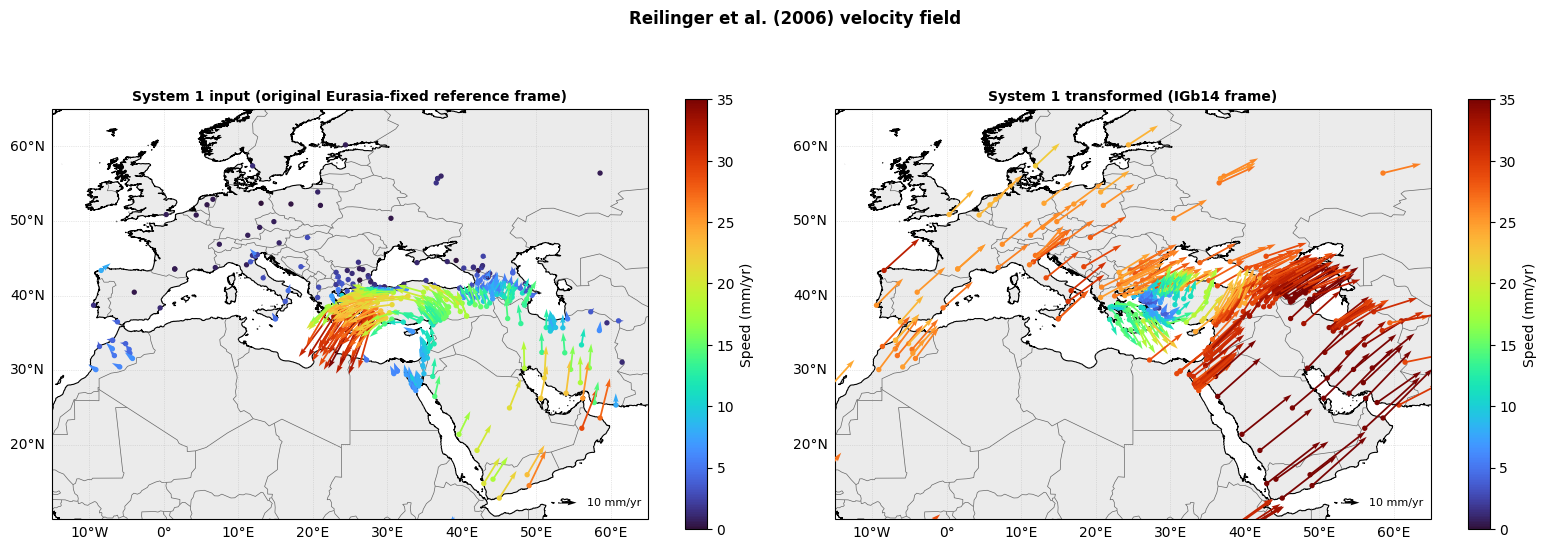

In [14]:
# Input sys1 velocities (from vel file)
df_in = parse_vel_file("data/reilinger_2006.vel")

# Transformed sys1 velocities (from PyVelrot)
df_out = df_py.copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, df, title in zip(
    axes,
    [df_in, df_out],
    ["System 1 input (original Eurasia-fixed reference frame)",
     "System 1 transformed (IGb14 frame)"]
):

    lons = df["lon"].values
    lats = df["lat"].values
    ve   = df["ve"].values
    vn   = df["vn"].values
    spd  = np.sqrt(ve**2 + vn**2)

    # Map extent
    ax.set_extent([-15, 65, 10, 65], crs=ccrs.PlateCarree())

    # Coastlines + map features
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.coastlines(resolution="10m", linewidth=0.8, zorder=2)
    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
        edgecolor="0.4",
        zorder=2
    )

    # Velocity magnitude points
    sc = ax.scatter(
        lons, lats,
        c=spd,
        cmap="turbo",
        s=8,
        vmin=0,
        vmax=35,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    # Velocity vectors
    Q = ax.quiver(
        lons, lats,
        ve, vn,
        spd,
        cmap="turbo",
        clim=(0, 35),
        scale=400,
        width=0.003,
        headwidth=3,
        transform=ccrs.PlateCarree(),
        zorder=4
    )

    ax.quiverkey(
        Q,
        0.88, 0.04,
        10,
        "10 mm/yr",
        labelpos="E",
        fontproperties={"size": 8}
    )

    ax.set_title(title, fontsize=10, fontweight="bold")

    gl = ax.gridlines(
        draw_labels=True,
        linestyle=":",
        linewidth=0.5,
        alpha=0.6
    )
    gl.top_labels = False
    gl.right_labels = False

    plt.colorbar(
        sc,
        ax=ax,
        label="Speed (mm/yr)",
        shrink=0.8
    )

fig.suptitle(
    "Reilinger et al. (2006) velocity field",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---
## Summary

| Quantity | Fortran | PyVelrot | Max difference |
|----------|---------|----------|----------------|
| Tx (mm/yr) | +0.755 ± 0.177 | +0.752 ± 0.176 | 0.003 |
| Ty (mm/yr) | +0.067 ± 0.237 | +0.067 ± 0.237 | 0.001 |
| Tz (mm/yr) | +0.700 ± 0.262 | +0.703 ± 0.262 | 0.003 |
| Rx (mas/yr) | −0.092 ± 0.006 | same | < 0.0001 |
| Ry (mas/yr) | −0.529 ± 0.008 | same | 0.0000 |
| Rz (mas/yr) | +0.749 ± 0.009 | same | < 0.0001 |
| RMS (mm/yr) | 0.72 | 0.72 | 0.00 |
| NRMS | 1.35 | 1.35 | 0.00 |
| East velocity | — | — | ≤ 0.01 mm/yr |
| North velocity | — | — | ≤ 0.01 mm/yr |
| Up velocity | — | — | ≤ 0.06 mm/yr |

**PyVelrot faithfully reproduces the Fortran `velrot` output.**

The ≤ 0.01 mm/yr horizontal residuals are display-precision rounding (the `.vel` format
stores velocities to 2 decimal places).  The ≤ 0.06 mm/yr vertical residual (~2% of
the 3 mm/yr vertical uncertainty) comes from floating-point differences between
`numpy.linalg.solve` / `inv` and Fortran's Gaussian-elimination solver `invert_vis`.
The two are mathematically equivalent; the discrepancy has no practical significance.